# 05 — Bitki Önerisi

Her lokasyon × yıl kombinasyonu için modelin tahmin ettiği en yüksek verimli bitkiyi öner.

**Strateji:** Normal senaryo, full-season baseline modeli  
**Çıktı:** Her grid noktası için önerilen bitki ve beklenen verim

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
from pathlib import Path

from src.data.loader import load_season_agg

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

PROCESSED = Path('../data/processed')
OUTPUTS   = Path('../outputs')
FIGS      = '../outputs/figures/'

## 1. Model ve veriyi yükle

In [2]:
model = joblib.load(OUTPUTS / 'models/baseline_lgbm_fullseason.joblib')
print('Model yüklendi.')

agg = load_season_agg()
print(f'Toplam satır: {len(agg):,}')

Model yüklendi.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Toplam satır: 53,184


## 2. Normal senaryo, başarılı hasatlar

In [3]:
df = agg[(agg['wav_scenario'] == 'normal') & (agg['sim_success'] == 1)].copy()
print(f'Normal senaryo, başarılı hasat: {len(df):,} satır')
print(f'Lokasyon sayısı: {df[["latitude", "longitude"]].drop_duplicates().shape[0]}')
print(f'Bitki sayısı: {df["crop_name"].nunique()}')

Normal senaryo, başarılı hasat: 13,988 satır
Lokasyon sayısı: 71
Bitki sayısı: 22


## 3. Target encoding (train verisiyle tutarlı)

In [4]:
import json

TARGET = 'harvest_twso'

with open(PROCESSED / 'crop_te_map.json') as f:
    crop_te_export = json.load(f)

global_mean = crop_te_export.pop('__global_mean__')
crop_te_map = crop_te_export  # {crop_name: mean_yield}

df['crop_te'] = df['crop_name'].map(crop_te_map).fillna(global_mean)
print('crop_te eklendi (02 notebook ile aynı mapping).')
print(df[['crop_name', 'crop_te']].drop_duplicates().sort_values('crop_te').to_string())

crop_te eklendi (02 notebook ile aynı mapping).
       crop_name      crop_te
477      tobacco    11.335393
85      chickpea    64.385510
105    groundnut   219.231781
98        cowpea   443.593454
222     mungbean   515.834191
10        cotton   521.271023
235         rice   555.421382
61     sunflower   613.178161
25        millet   687.346287
56       soybean  1092.451290
4        cassava  1098.829701
53       sorghum  1171.326110
46      rapeseed  1489.253652
35     pigeonpea  1908.833900
64   sweetpotato  2115.445476
40        potato  2201.424793
111        maize  2204.834833
19      fababean  4047.227872
147    sugarbeet  4479.661070
175       barley  4798.587416
167        wheat  4813.100935
76    seed_onion  5425.534632


## 4. Model tahmini

In [5]:
FEATURE_COLS = [
    'mean_temp', 'total_precip', 'mean_humidity', 'mean_rftra',
    'max_lai', 'max_tagp', 'max_dvs', 'season_days',
    'latitude', 'longitude', 'elevation', 'year', 'WAV', 'crop_te',
]

df['predicted_twso'] = model.predict(df[FEATURE_COLS])
print(f'Tahmin tamamlandı. Örnek:')
df[['latitude', 'longitude', 'crop_name', 'harvest_twso', 'predicted_twso']].head()

Tahmin tamamlandı. Örnek:


,latitude,longitude,crop_name,harvest_twso,predicted_twso
4,36.0,42.5,cassava,0.928732,41.382625
10,37.0,38.0,cotton,193.782127,195.410209
19,40.0,33.5,fababean,1672.813786,1727.574679
25,40.0,35.0,millet,527.243053,384.502801
27,40.0,36.5,millet,521.646984,436.195846


## 5. Her lokasyon × yıl için en iyi bitkiyi seç

In [6]:
best = (
    df.loc[df.groupby(['latitude', 'longitude', 'year'])['predicted_twso'].idxmax()]
    [['latitude', 'longitude', 'year', 'crop_name', 'predicted_twso', 'harvest_twso']]
    .reset_index(drop=True)
)

print(f'Öneri sayısı: {len(best):,}')
print('\nEn sık önerilen bitkiler:')
print(best['crop_name'].value_counts())

Öneri sayısı: 772

En sık önerilen bitkiler:
crop_name
barley         218
seed_onion     196
fababean       143
wheat          101
sugarbeet       86
pigeonpea       16
maize            6
sweetpotato      4
potato           2
Name: count, dtype: int64


## 6. Harita — en son yıl için önerilen bitki

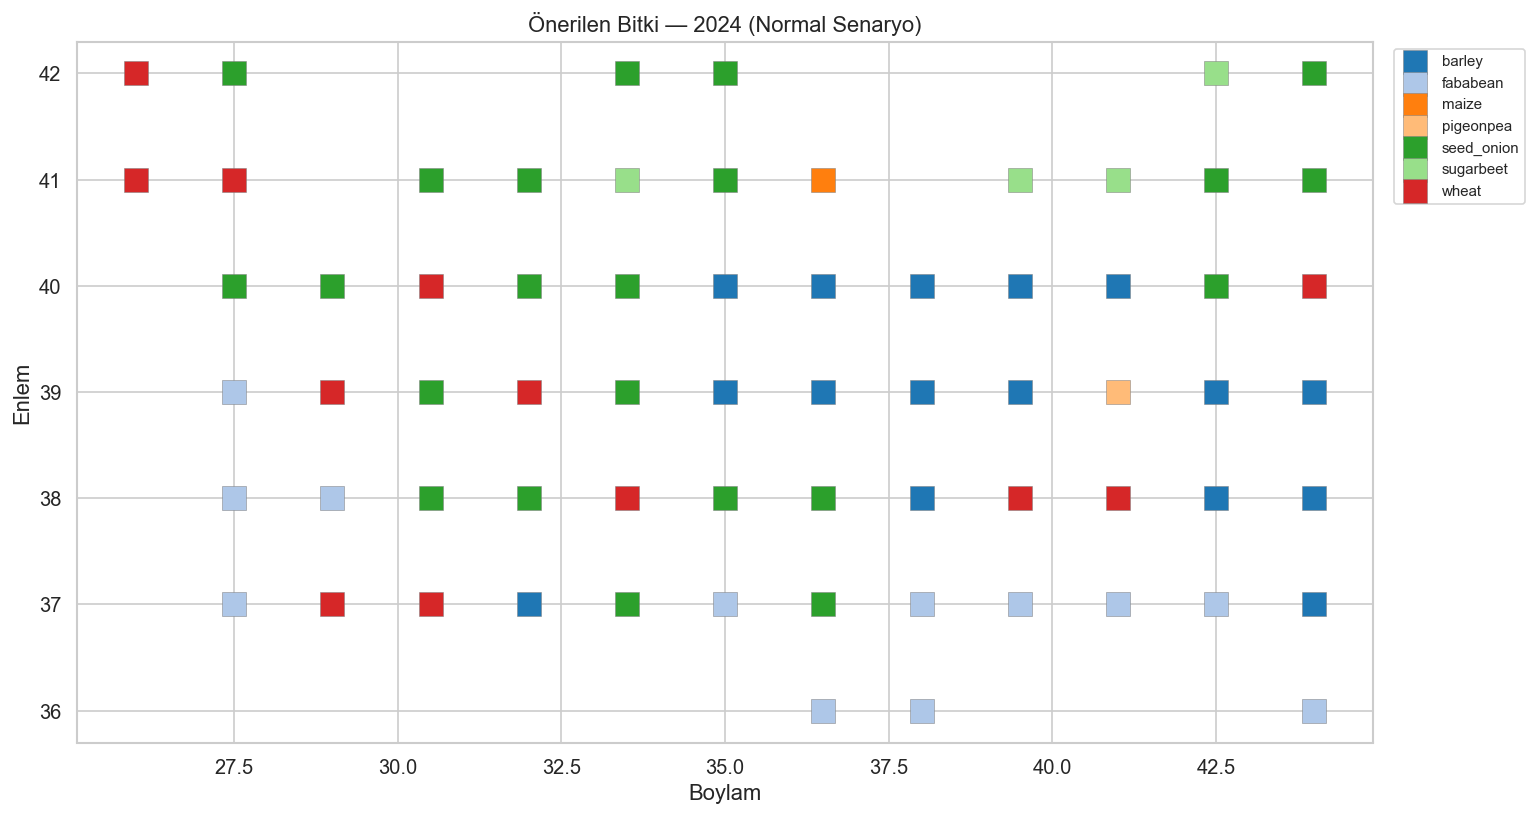

In [7]:
last_year = best['year'].max()
map_df = best[best['year'] == last_year].copy()

crops = sorted(map_df['crop_name'].unique())
palette = sns.color_palette('tab20', len(crops))
color_map = dict(zip(crops, palette))

fig, ax = plt.subplots(figsize=(13, 7))
for crop, grp in map_df.groupby('crop_name'):
    ax.scatter(grp['longitude'], grp['latitude'],
               color=color_map[crop], s=200, marker='s',
               edgecolors='gray', linewidths=0.3, label=crop)

ax.set_xlabel('Boylam')
ax.set_ylabel('Enlem')
ax.set_title(f'Önerilen Bitki — {last_year} (Normal Senaryo)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(FIGS + 'crop_recommendation_map.png', bbox_inches='tight')
plt.show()

## 7. Bölge bazında öneri tutarlılığı (yıllar arası)

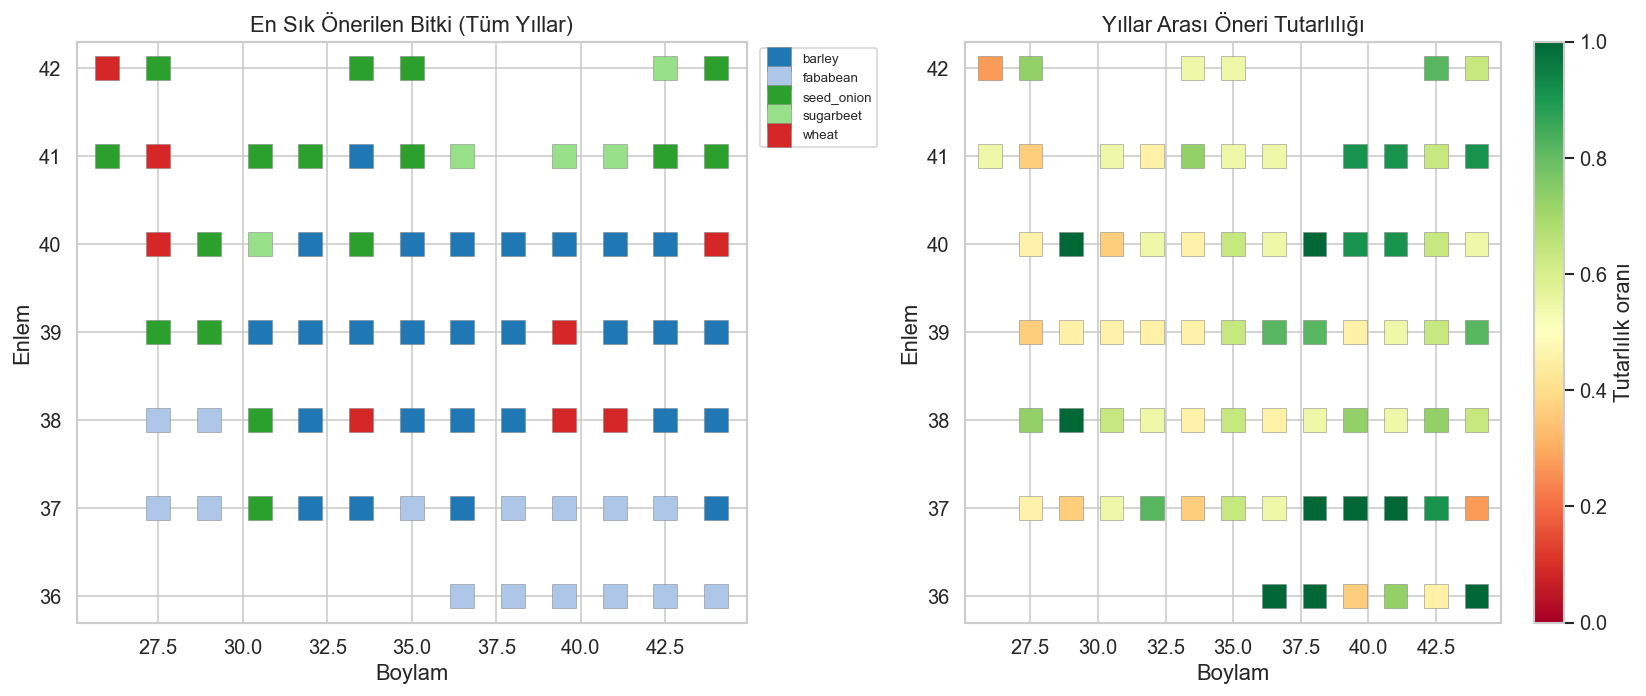

In [8]:
# Her lokasyon için en sık önerilen bitki ve tutarlılık oranı
consistency = (
    best.groupby(['latitude', 'longitude', 'crop_name'])
    .size().reset_index(name='count')
    .sort_values('count', ascending=False)
)
total_years = best['year'].nunique()
top_crop = (
    consistency.loc[consistency.groupby(['latitude', 'longitude'])['count'].idxmax()]
    .assign(consistency=lambda d: d['count'] / total_years)
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Sol: en sık önerilen bitki
for crop, grp in top_crop.groupby('crop_name'):
    axes[0].scatter(grp['longitude'], grp['latitude'],
                    color=color_map.get(crop, 'gray'), s=200, marker='s',
                    edgecolors='gray', linewidths=0.3, label=crop)
axes[0].set_title('En Sık Önerilen Bitki (Tüm Yıllar)')
axes[0].set_xlabel('Boylam')
axes[0].set_ylabel('Enlem')
axes[0].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

# Sağ: tutarlılık oranı
sc = axes[1].scatter(top_crop['longitude'], top_crop['latitude'],
                     c=top_crop['consistency'], cmap='RdYlGn',
                     s=200, marker='s', edgecolors='gray', linewidths=0.3,
                     vmin=0, vmax=1)
plt.colorbar(sc, ax=axes[1], label='Tutarlılık oranı')
axes[1].set_title('Yıllar Arası Öneri Tutarlılığı')
axes[1].set_xlabel('Boylam')
axes[1].set_ylabel('Enlem')

plt.tight_layout()
plt.savefig(FIGS + 'crop_recommendation_consistency.png', bbox_inches='tight')
plt.show()

## 8. Kaydet

In [9]:
best.to_parquet(OUTPUTS / 'crop_recommendations.parquet', index=False)
top_crop.to_parquet(OUTPUTS / 'crop_recommendations_consistency.parquet', index=False)
print('Kaydedildi.')
print(best.head())

Kaydedildi.
   latitude  longitude  year crop_name  predicted_twso  harvest_twso
0      36.0       36.5  2014  fababean     8915.158163   8986.352480
1      36.0       36.5  2015  fababean     7079.995317   6946.548214
2      36.0       36.5  2016  fababean     6533.867005   6720.796170
3      36.0       36.5  2017  fababean     6966.141011   7064.741850
4      36.0       36.5  2018  fababean     8796.277802   8847.168354
